In [21]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Layer, Concatenate, Dot, Activation
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv("D57000_complete.csv", sep=";")
df["Titulo"] = df["Titulo"].astype(str)
df["Descripcion"] = df["Descripcion"].astype(str)

REAL_LABEL = 1       
df = df[df["Label"] == REAL_LABEL].reset_index(drop=True)

src_texts = df["Descripcion"].astype(str).tolist()
tgt_texts = df["Titulo"].astype(str).tolist()

tgt_in_texts  = ["<sos> " + t for t in tgt_texts]
tgt_out_texts = [t + " <eos>" for t in tgt_texts]

max_words = 10000
src_tk = Tokenizer(num_words=max_words, oov_token="<UNK>")
tgt_tk = Tokenizer(num_words=max_words, oov_token="<UNK>")

src_tk.fit_on_texts(src_texts)
tgt_tk.fit_on_texts(tgt_in_texts + tgt_out_texts)

max_len_src = 50
max_len_tgt = 15

src_seq     = pad_sequences(src_tk.texts_to_sequences(src_texts),     maxlen=max_len_src, padding="post")
tgt_in_seq  = pad_sequences(tgt_tk.texts_to_sequences(tgt_in_texts),  maxlen=max_len_tgt, padding="post")
tgt_out_seq = pad_sequences(tgt_tk.texts_to_sequences(tgt_out_texts), maxlen=max_len_tgt, padding="post")

num_encoder_tokens = min(max_words, len(src_tk.word_index) + 1)
num_decoder_tokens = min(max_words, len(tgt_tk.word_index) + 1)

BAHDANAU

In [23]:
class BahdanauAttention(Layer):
    """
    Mecanismo de atención aditiva (Bahdanau et al., 2015)
    Procesa todas las secuencias de tiempo a la vez
    CON SOPORTE PARA MÁSCARAS
    """
    def __init__(self, units, **kwargs):
        super(BahdanauAttention, self).__init__(**kwargs)
        self.W1 = Dense(units, use_bias=False)
        self.W2 = Dense(units, use_bias=False)
        self.V = Dense(1, use_bias=False)
        self.supports_masking = True  # Habilitar soporte de máscaras
        
    def call(self, inputs, mask=None):
        """
        inputs: [decoder_hidden, encoder_outputs]
        decoder_hidden: (batch_size, max_len_tgt, hidden_size)
        encoder_outputs: (batch_size, max_len_src, hidden_size)
        mask: [decoder_mask, encoder_mask] o None
        """
        decoder_hidden, encoder_outputs = inputs
        
        # Expandir encoder_outputs para broadcast con decoder
        # (batch, max_len_tgt, max_len_src, hidden_size)
        encoder_expanded = tf.expand_dims(encoder_outputs, 1)
        encoder_expanded = tf.tile(encoder_expanded, [1, tf.shape(decoder_hidden)[1], 1, 1])
        
        # Expandir decoder_hidden
        # (batch, max_len_tgt, 1, hidden_size)
        decoder_expanded = tf.expand_dims(decoder_hidden, 2)
        decoder_expanded = tf.tile(decoder_expanded, [1, 1, tf.shape(encoder_outputs)[1], 1])
        
        # Calcular scores
        # (batch, max_len_tgt, max_len_src, 1)
        score = self.V(tf.nn.tanh(
            self.W1(decoder_expanded) + self.W2(encoder_expanded)
        ))
        
        # Aplicar máscara del encoder si existe
        if mask is not None:
            # mask es una lista [decoder_mask, encoder_mask]
            encoder_mask = mask[1] if isinstance(mask, (list, tuple)) else None
            if encoder_mask is not None:
                # Expandir máscara: (batch, 1, max_len_src, 1)
                encoder_mask = tf.expand_dims(tf.expand_dims(encoder_mask, 1), -1)
                encoder_mask = tf.cast(encoder_mask, tf.float32)
                # Aplicar máscara (-inf en posiciones de padding)
                score = tf.where(
                    tf.equal(encoder_mask, 0),
                    tf.ones_like(score) * -1e9,
                    score
                )
        
        # Calcular pesos de atención
        # (batch, max_len_tgt, max_len_src, 1)
        attention_weights = tf.nn.softmax(score, axis=2)
        
        # Calcular vector de contexto
        # (batch, max_len_tgt, max_len_src, hidden_size)
        context_vector = attention_weights * encoder_expanded
        # (batch, max_len_tgt, hidden_size)
        context_vector = tf.reduce_sum(context_vector, axis=2)
        
        return context_vector, attention_weights
    
    def compute_mask(self, inputs, mask=None):
        # La salida mantiene la máscara del decoder
        if mask is not None:
            if isinstance(mask, (list, tuple)):
                return mask[0]  # Retornar máscara del decoder
        return None


LUONG

In [24]:
class LuongAttention(Layer):
    """
    Mecanismo de atención multiplicativa (Luong et al., 2015)
    Implementa el método 'general'
    CON SOPORTE PARA MÁSCARAS
    """
    def __init__(self, units, **kwargs):
        super(LuongAttention, self).__init__(**kwargs)
        self.W = Dense(units, use_bias=False)
        self.supports_masking = True  # Habilitar soporte de máscaras
        
    def call(self, inputs, mask=None):
        """
        inputs: [decoder_hidden, encoder_outputs]
        decoder_hidden: (batch_size, max_len_tgt, hidden_size)
        encoder_outputs: (batch_size, max_len_src, hidden_size)
        mask: [decoder_mask, encoder_mask] o None
        """
        decoder_hidden, encoder_outputs = inputs
        
        # Aplicar transformación al decoder hidden
        # (batch, max_len_tgt, hidden_size)
        decoder_transformed = self.W(decoder_hidden)
        
        # Calcular scores usando batch matmul
        # (batch, max_len_tgt, max_len_src)
        score = tf.matmul(decoder_transformed, encoder_outputs, transpose_b=True)
        
        # Aplicar máscara del encoder si existe
        if mask is not None:
            # mask es una lista [decoder_mask, encoder_mask]
            encoder_mask = mask[1] if isinstance(mask, (list, tuple)) else None
            if encoder_mask is not None:
                # Expandir máscara: (batch, 1, max_len_src)
                encoder_mask = tf.expand_dims(encoder_mask, 1)
                encoder_mask = tf.cast(encoder_mask, tf.float32)
                # Aplicar máscara (-inf en posiciones de padding)
                score = tf.where(
                    tf.equal(encoder_mask, 0),
                    tf.ones_like(score) * -1e9,
                    score
                )
        
        # Calcular pesos de atención
        # (batch, max_len_tgt, max_len_src)
        attention_weights = tf.nn.softmax(score, axis=-1)
        
        # Calcular vector de contexto
        # (batch, max_len_tgt, hidden_size)
        context_vector = tf.matmul(attention_weights, encoder_outputs)
        
        # Expandir dimensión para consistencia con Bahdanau
        attention_weights = tf.expand_dims(attention_weights, -1)
        
        return context_vector, attention_weights
    
    def compute_mask(self, inputs, mask=None):
        # La salida mantiene la máscara del decoder
        if mask is not None:
            if isinstance(mask, (list, tuple)):
                return mask[0]  # Retornar máscara del decoder
        return None

Seq2Seq con Atención

In [25]:
def build_seq2seq_with_attention(attention_type='bahdanau'):
    """
    Construye modelo Seq2Seq con mecanismo de atención
    
    Args:
        attention_type: 'bahdanau' o 'luong'
    """
    latent_dim = 128
    embedding_dim = 100
    
    # ===== ENCODER =====
    encoder_inputs = Input(shape=(max_len_src,), name='encoder_inputs')
    enc_emb = Embedding(
        input_dim=num_encoder_tokens, 
        output_dim=embedding_dim, 
        mask_zero=True,
        name='encoder_embedding'
    )(encoder_inputs)
    
    encoder_lstm = LSTM(
        latent_dim, 
        return_sequences=True,  # Necesario para atención
        return_state=True,
        name='encoder_lstm'
    )
    encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)
    encoder_states = [state_h, state_c]
    
    # ===== DECODER =====
    decoder_inputs = Input(shape=(max_len_tgt,), name='decoder_inputs')
    dec_emb_layer = Embedding(
        input_dim=num_decoder_tokens, 
        output_dim=embedding_dim,
        mask_zero=True,
        name='decoder_embedding'
    )
    dec_emb = dec_emb_layer(decoder_inputs)
    
    decoder_lstm = LSTM(
        latent_dim, 
        return_sequences=True,  # Devuelve secuencia completa
        return_state=True,
        name='decoder_lstm'
    )
    decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)
    
    # ===== CAPA DE ATENCIÓN =====
    if attention_type == 'bahdanau':
        attention_layer = BahdanauAttention(latent_dim, name='bahdanau_attention')
    elif attention_type == 'luong':
        attention_layer = LuongAttention(latent_dim, name='luong_attention')
    else:
        raise ValueError("attention_type debe ser 'bahdanau' o 'luong'")
    
    # Aplicar atención (procesa toda la secuencia a la vez)
    # La capa espera recibir inputs como lista y mask automáticamente
    context_vector, attention_weights = attention_layer([decoder_outputs, encoder_outputs])
    
    # Concatenar contexto con salida del decoder
    decoder_combined = Concatenate(axis=-1, name='concat_context')([
        decoder_outputs, 
        context_vector
    ])
    
    # Capa densa final
    decoder_dense = Dense(num_decoder_tokens, activation='softmax', name='output_softmax')
    final_outputs = decoder_dense(decoder_combined)
    
    # Modelo completo
    model = Model(
        [encoder_inputs, decoder_inputs], 
        final_outputs,
        name=f'seq2seq_{attention_type}'
    )
    
    # Modelo para extraer pesos de atención (para visualización)
    attention_model = Model(
        [encoder_inputs, decoder_inputs],
        attention_weights,
        name=f'attention_weights_{attention_type}'
    )
    
    return model, attention_model

Construcción Modelos

In [26]:
model_bahdanau, attention_model_bahdanau = build_seq2seq_with_attention('bahdanau')
model_bahdanau.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_bahdanau.summary()

Model: "seq2seq_bahdanau"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 50, 100)   │  1,000,000 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_8         │ (None, 50)        │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 15, 100)   │  1,000,000 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 50, 128), │    117,248 │ encoder_embeddin… │
│                     │ (None, 128),      │            │ not_equal_8[0][0] │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 15, 128), │    117,248 │ decoder_embeddin… │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_9         │ (None, 15)        │          0 │ decoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bahdanau_attention  │ [(None, 15, 128), │     32,896 │ decoder_lstm[0][… │
│ (BahdanauAttention) │ (None, 15, 50,    │            │ encoder_lstm[0][… │
│                     │ 1)]               │            │ not_equal_9[0][0… │
│                     │                   │            │ not_equal_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_context      │ (None, 15, 256)   │          0 │ decoder_lstm[0][… │
│ (Concatenate)       │                   │            │ bahdanau_attenti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_softmax      │ (None, 15, 10000) │  2,570,000 │ concat_context[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,837,392 (18.45 MB)

 Trainable params: 4,837,392 (18.45 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model_luong, attention_model_luong = build_seq2seq_with_attention('luong')
model_luong.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_luong.summary()

Model: "seq2seq_luong"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 50, 100)   │  1,000,000 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_10        │ (None, 50)        │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 15, 100)   │  1,000,000 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 50, 128), │    117,248 │ encoder_embeddin… │
│                     │ (None, 128),      │            │ not_equal_10[0][… │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 15, 128), │    117,248 │ decoder_embeddin… │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_11        │ (None, 15)        │          0 │ decoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ luong_attention     │ [(None, 15, 128), │     16,384 │ decoder_lstm[0][… │
│ (LuongAttention)    │ (None, 15, 50,    │            │ encoder_lstm[0][… │
│                     │ 1)]               │            │ not_equal_11[0][… │
│                     │                   │            │ not_equal_10[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_context      │ (None, 15, 256)   │          0 │ decoder_lstm[0][… │
│ (Concatenate)       │                   │            │ luong_attention[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_softmax      │ (None, 15, 10000) │  2,570,000 │ concat_context[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,820,880 (18.39 MB)

 Trainable params: 4,820,880 (18.39 MB)

 Non-trainable params: 0 (0.00 B)

Entrenamiento Modelos

In [28]:
history_bahdanau = model_bahdanau.fit(
    [src_seq, tgt_in_seq],
    np.expand_dims(tgt_out_seq, -1),
    batch_size=128,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 250s 1s/step - accuracy: 0.0963 - loss: 6.8538 - val_accuracy: 0.1686 - val_loss: 5.5138
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - accuracy: 0.1747 - loss: 5.3947 - val_accuracy: 0.1909 - val_loss: 5.1627
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 230s 980ms/step - accuracy: 0.1990 - loss: 5.0593 - val_accuracy: 0.2028 - val_loss: 4.9751
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 229s 973ms/step - accuracy: 0.2105 - loss: 4.8662 - val_accuracy: 0.2114 - val_loss: 4.8481
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 230s 980ms/step - accuracy: 0.2187 - loss: 4.7184 - val_accuracy: 0.2184 - val_loss: 4.7432
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 232s 988ms/step - accuracy: 0.2279 - loss: 4.5850 - val_accuracy: 0.2215 - val_loss: 4.6555
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 235s 998ms/step - accuracy: 0.2355 - loss: 4.4576 - val_accuracy: 0.2291 - val_loss: 4.5694
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.2424 - loss: 4.

In [ ]:
history_luong = model_luong.fit(
    [src_seq, tgt_in_seq],
    np.expand_dims(tgt_out_seq, -1),
    batch_size=128,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

Visualizar Resultados

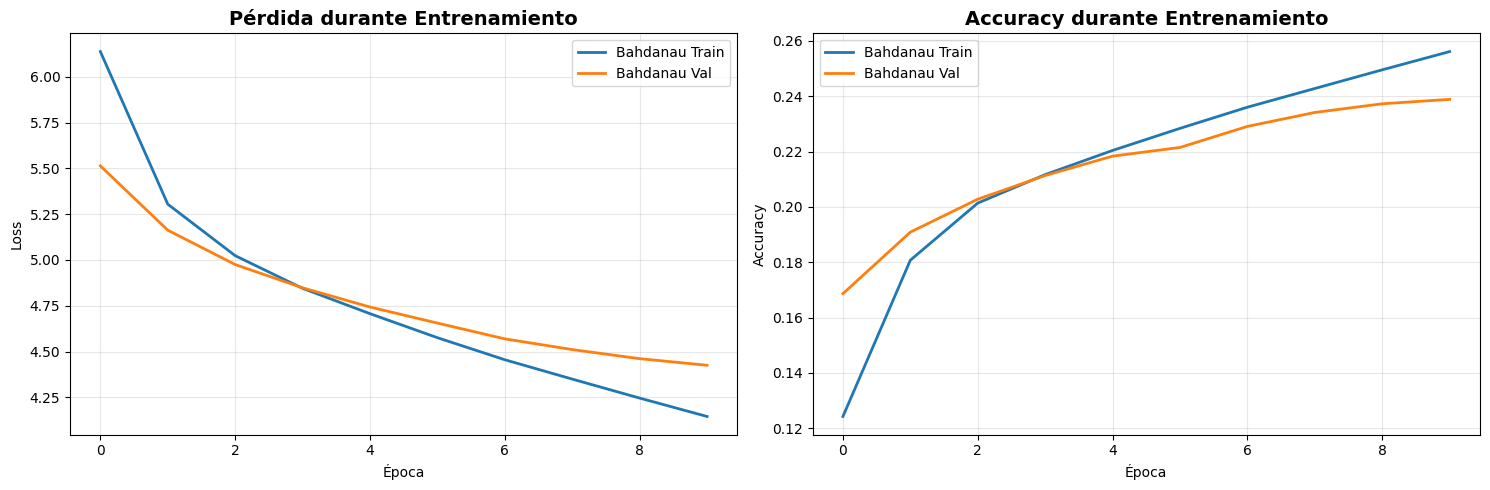

In [30]:
def plot_training_history(history_bahdanau, history_luong):
    """Compara el entrenamiento de ambos modelos"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss
    axes[0].plot(history_bahdanau.history['loss'], label='Bahdanau Train', linewidth=2)
    axes[0].plot(history_bahdanau.history['val_loss'], label='Bahdanau Val', linewidth=2)
    #axes[0].plot(history_luong.history['loss'], label='Luong Train', linewidth=2, linestyle='--')
    #axes[0].plot(history_luong.history['val_loss'], label='Luong Val', linewidth=2, linestyle='--')
    axes[0].set_title('Pérdida durante Entrenamiento', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(history_bahdanau.history['accuracy'], label='Bahdanau Train', linewidth=2)
    axes[1].plot(history_bahdanau.history['val_accuracy'], label='Bahdanau Val', linewidth=2)
    #axes[1].plot(history_luong.history['accuracy'], label='Luong Train', linewidth=2, linestyle='--')
    #axes[1].plot(history_luong.history['val_accuracy'], label='Luong Val', linewidth=2, linestyle='--')
    axes[1].set_title('Accuracy durante Entrenamiento', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('comparacion_entrenamiento.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history_bahdanau, 0)

In [31]:
def visualize_attention(attention_model, src_seq_sample, tgt_in_seq_sample, 
                       src_text, tgt_text, attention_type):
    """
    Visualiza el mapa de atención para una muestra
    """
    # Obtener pesos de atención
    sample_src = src_seq_sample.reshape(1, -1)
    sample_tgt = tgt_in_seq_sample.reshape(1, -1)
    
    attention_weights = attention_model.predict([sample_src, sample_tgt], verbose=0)
    
    # attention_weights shape: (1, max_len_tgt, max_len_src, 1)
    attention_weights = attention_weights[0, :, :, 0]  # (max_len_tgt, max_len_src)
    
    # Crear etiquetas para los ejes
    src_tokens = src_text.split()[:max_len_src]
    tgt_tokens = tgt_text.split()[:max_len_tgt]
    
    # Si hay menos tokens que la longitud máxima, rellenar con vacíos
    src_labels = [f"{i}:{t[:8]}" for i, t in enumerate(src_tokens)]
    src_labels += [f"{i}:PAD" for i in range(len(src_tokens), max_len_src)]
    
    tgt_labels = [f"{i}:{t[:8]}" for i, t in enumerate(tgt_tokens)]
    tgt_labels += [f"{i}:PAD" for i in range(len(tgt_tokens), max_len_tgt)]
    
    # Visualizar
    plt.figure(figsize=(16, 8))
    sns.heatmap(
        attention_weights.T,
        cmap='YlOrRd',
        xticklabels=tgt_labels,
        yticklabels=src_labels,
        cbar_kws={'label': 'Peso de Atención'},
        vmin=0,
        vmax=attention_weights.max()
    )
    plt.title(f'Mapa de Atención - {attention_type.capitalize()}\nFuente: {src_text[:60]}...\nObjetivo: {tgt_text}', 
              fontsize=11, fontweight='bold')
    plt.xlabel('Posición en Salida (Decoder)', fontsize=10)
    plt.ylabel('Posición en Entrada (Encoder)', fontsize=10)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'atencion_{attention_type}_ejemplo.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return attention_weights

Descripción: Núñez Feijóo guarda silencio pero Ayuso y Almeida aprovechan la polémica para asumir las tesis provida de la extrema derecha.
Título: El PP se rinde al discurso antiabortista de Vox en pleno año electoral


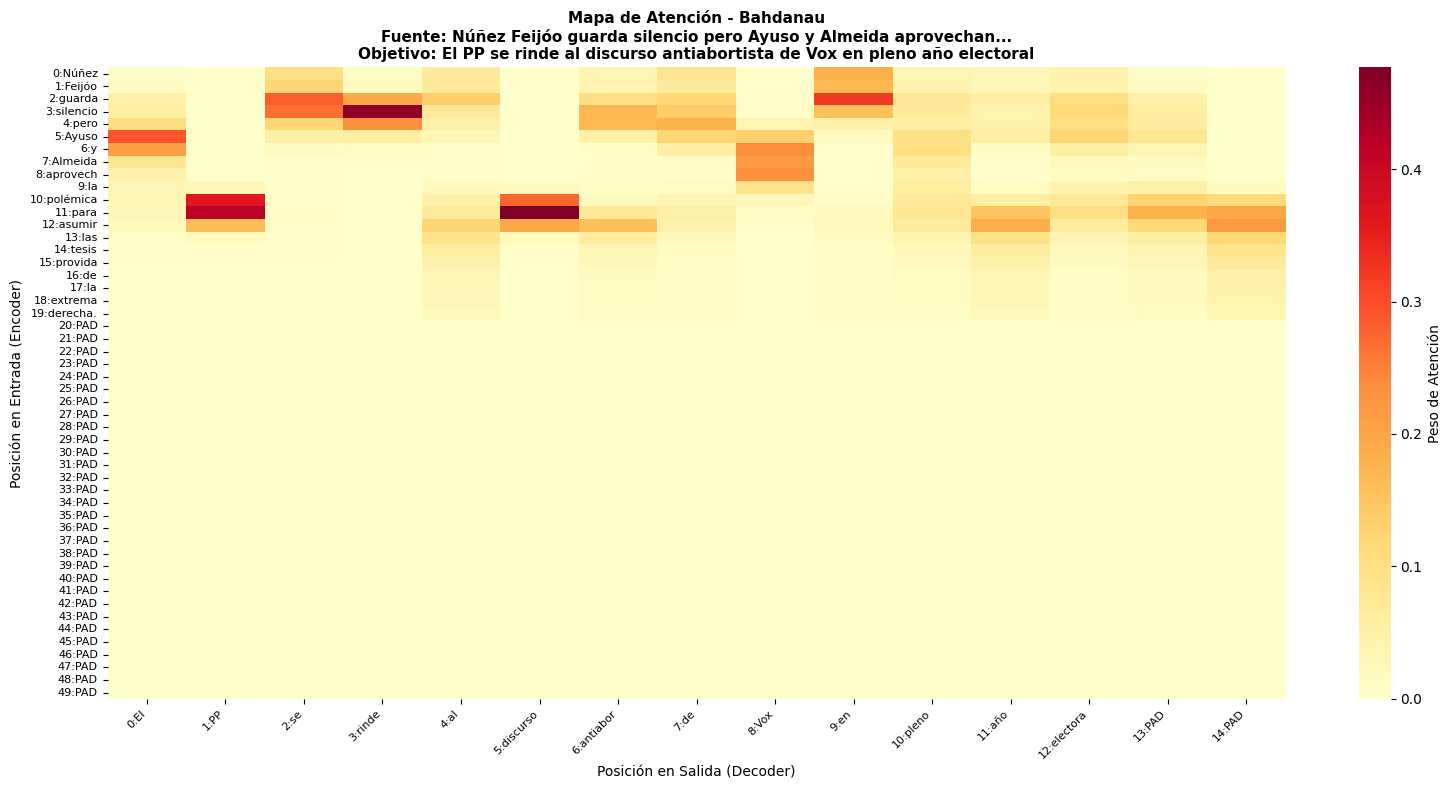

In [34]:
idx = 5
print(f"Descripción: {src_texts[idx]}")
print(f"Título: {tgt_texts[idx]}")
attention_bahdanau = visualize_attention(
    attention_model_bahdanau, 
    src_seq[idx], 
    tgt_in_seq[idx],
    src_texts[idx],
    tgt_texts[idx],
    'bahdanau'
)

In [ ]:
attention_luong = visualize_attention(
    attention_model_luong, 
    src_seq[idx], 
    tgt_in_seq[idx],
    src_texts[idx],
    tgt_texts[idx],
    'luong'
)

Guardado por largo entrenamiento

In [37]:
model_bahdanau.save('seq2seq_bahdanau_attention.keras')
#model_luong.save('seq2seq_luong_attention.keras')

In [38]:
print(f"Bahdanau - Val Loss: {history_bahdanau.history['val_loss'][-1]:.4f}, Val Acc: {history_bahdanau.history['val_accuracy'][-1]:.4f}")
#print(f"Luong    - Val Loss: {history_luong.history['val_loss'][-1]:.4f}, Val Acc: {history_luong.history['val_accuracy'][-1]:.4f}")

Bahdanau - Val Loss: 4.4253, Val Acc: 0.2389


# Métricas

In [40]:
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
import nltk

In [41]:
try:
    nltk.data.find('wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('omw-1.4')
except LookupError:
    nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\PMarr\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\PMarr\AppData\Roaming\nltk_data...


In [42]:
id_to_word_tgt = {idx: word for word, idx in tgt_tk.word_index.items()}
id_to_word_tgt[0] = '<PAD>'

# Usar datos de validación (último 10%)
split_idx = int(len(src_seq) * 0.9)
val_src_seq = src_seq[split_idx:]
val_tgt_in_seq = tgt_in_seq[split_idx:]
val_tgt_out_seq = tgt_out_seq[split_idx:]
val_tgt_texts = tgt_texts[split_idx:]

In [43]:
def decode_sequence(model, input_seq, max_len=15):
    """
    Decodifica una secuencia usando el modelo
    """
    # Iniciar con token <sos>
    sos_token = tgt_tk.word_index.get('<sos>', 1)
    target_seq = np.zeros((1, max_len))
    target_seq[0, 0] = sos_token
    
    # Generar secuencia palabra por palabra
    for i in range(1, max_len):
        predictions = model.predict([input_seq, target_seq], verbose=0)
        # Tomar el token con mayor probabilidad en la posición actual
        predicted_id = np.argmax(predictions[0, i-1, :])
        
        # Si predice <eos>, terminar
        if predicted_id == tgt_tk.word_index.get('<eos>', 2) or predicted_id == 0:
            break
            
        target_seq[0, i] = predicted_id
    
    # Convertir a texto
    decoded_words = []
    for idx in target_seq[0]:
        if idx == 0 or idx == tgt_tk.word_index.get('<sos>', 1):
            continue
        if idx == tgt_tk.word_index.get('<eos>', 2):
            break
        word = id_to_word_tgt.get(idx, '<UNK>')
        decoded_words.append(word)
    
    return ' '.join(decoded_words)

def batch_decode(model, input_seqs, batch_size=32):
    """
    Decodifica múltiples secuencias en lotes
    """
    predictions = []
    n_batches = int(np.ceil(len(input_seqs) / batch_size))
    
    for i in range(n_batches):
        if i % 10 == 0:
            print(f"  Procesando lote {i+1}/{n_batches}", end='\r')
        
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, len(input_seqs))
        batch = input_seqs[start_idx:end_idx]
        
        for seq in batch:
            pred = decode_sequence(model, seq.reshape(1, -1))
            predictions.append(pred)
    
    print(f"  ✓ Procesados {len(predictions)} ejemplos      ")
    return predictions


In [44]:
predictions = {}

predictions['bahdanau'] = batch_decode(model_bahdanau, val_src_seq)
#predictions['luong'] = batch_decode(model_luong, val_src_seq)

  ✓ Procesados 3336 ejemplos      


In [45]:
def calculate_bleu_scores(references, hypotheses):
    """Calcula BLEU-1, BLEU-2, BLEU-3, BLEU-4"""
    smooth = SmoothingFunction()
    
    bleu_1_scores = []
    bleu_2_scores = []
    bleu_3_scores = []
    bleu_4_scores = []
    
    refs_corpus = []
    hyps_corpus = []
    
    for ref, hyp in zip(references, hypotheses):
        ref_tokens = ref.lower().split()
        hyp_tokens = hyp.lower().split()
        
        refs_corpus.append([ref_tokens])
        hyps_corpus.append(hyp_tokens)
        
        bleu_1 = sentence_bleu([ref_tokens], hyp_tokens, weights=(1, 0, 0, 0), 
                              smoothing_function=smooth.method1)
        bleu_2 = sentence_bleu([ref_tokens], hyp_tokens, weights=(0.5, 0.5, 0, 0),
                              smoothing_function=smooth.method1)
        bleu_3 = sentence_bleu([ref_tokens], hyp_tokens, weights=(0.33, 0.33, 0.33, 0),
                              smoothing_function=smooth.method1)
        bleu_4 = sentence_bleu([ref_tokens], hyp_tokens, weights=(0.25, 0.25, 0.25, 0.25),
                              smoothing_function=smooth.method1)
        
        bleu_1_scores.append(bleu_1)
        bleu_2_scores.append(bleu_2)
        bleu_3_scores.append(bleu_3)
        bleu_4_scores.append(bleu_4)
    
    corpus_bleu_score = corpus_bleu(refs_corpus, hyps_corpus)
    
    return {
        'BLEU-1': np.mean(bleu_1_scores),
        'BLEU-2': np.mean(bleu_2_scores),
        'BLEU-3': np.mean(bleu_3_scores),
        'BLEU-4': np.mean(bleu_4_scores),
        'BLEU-Corpus': corpus_bleu_score
    }

def calculate_rouge_scores(references, hypotheses):
    """Calcula ROUGE-1, ROUGE-2, ROUGE-L"""
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    
    rouge1_f = []
    rouge2_f = []
    rougeL_f = []
    
    for ref, hyp in zip(references, hypotheses):
        scores = scorer.score(ref, hyp)
        rouge1_f.append(scores['rouge1'].fmeasure)
        rouge2_f.append(scores['rouge2'].fmeasure)
        rougeL_f.append(scores['rougeL'].fmeasure)
    
    return {
        'ROUGE-1': np.mean(rouge1_f),
        'ROUGE-2': np.mean(rouge2_f),
        'ROUGE-L': np.mean(rougeL_f)
    }

def calculate_exact_match(references, hypotheses):
    """Calcula porcentaje de coincidencias exactas"""
    exact_matches = sum(1 for ref, hyp in zip(references, hypotheses) 
                       if ref.lower().strip() == hyp.lower().strip())
    return exact_matches / len(references) * 100

def calculate_meteor(references, hypotheses):
    """Calcula METEOR score"""
    meteor_scores = []
    for ref, hyp in zip(references, hypotheses):
        try:
            score = meteor_score([ref.lower().split()], hyp.lower().split())
            meteor_scores.append(score)
        except:
            meteor_scores.append(0.0)
    return np.mean(meteor_scores)

def calculate_length_stats(references, hypotheses):
    """Calcula estadísticas de longitud"""
    ref_lengths = [len(ref.split()) for ref in references]
    hyp_lengths = [len(hyp.split()) for hyp in hypotheses]
    
    return {
        'Ref_Avg_Length': np.mean(ref_lengths),
        'Hyp_Avg_Length': np.mean(hyp_lengths),
        'Length_Ratio': np.mean(hyp_lengths) / np.mean(ref_lengths) if np.mean(ref_lengths) > 0 else 0
    }

In [46]:
results = {}

for model_name, preds in predictions.items():
    print(f"\n{model_name.upper()}:")
    
    # BLEU
    print("  Calculando BLEU...")
    bleu_scores = calculate_bleu_scores(val_tgt_texts, preds)
    
    # ROUGE
    print("  Calculando ROUGE...")
    rouge_scores = calculate_rouge_scores(val_tgt_texts, preds)
    
    # METEOR
    print("  Calculando METEOR...")
    meteor = calculate_meteor(val_tgt_texts, preds)
    
    # Exact Match
    exact_match = calculate_exact_match(val_tgt_texts, preds)
    
    # Length Stats
    length_stats = calculate_length_stats(val_tgt_texts, preds)
    
    # Combinar resultados
    results[model_name] = {
        **bleu_scores,
        **rouge_scores,
        'METEOR': meteor,
        'Exact_Match_%': exact_match,
        **length_stats
    }
    


BAHDANAU:
  Calculando BLEU...


c:\Users\PMarr\AppData\Local\Programs\Python\Python311\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


  Calculando ROUGE...
  Calculando METEOR...


In [48]:
results_df = pd.DataFrame(results).T
results_df

,BLEU-1,BLEU-2,BLEU-3,BLEU-4,BLEU-Corpus,ROUGE-1,ROUGE-2,ROUGE-L,METEOR,Exact_Match_%,Ref_Avg_Length,Hyp_Avg_Length,Length_Ratio
bahdanau,0.001517,0.000586,0.000433,0.000361,7.682634e-94,0.016796,0.001589,0.015221,0.006532,0.0,15.563549,0.449341,0.028871


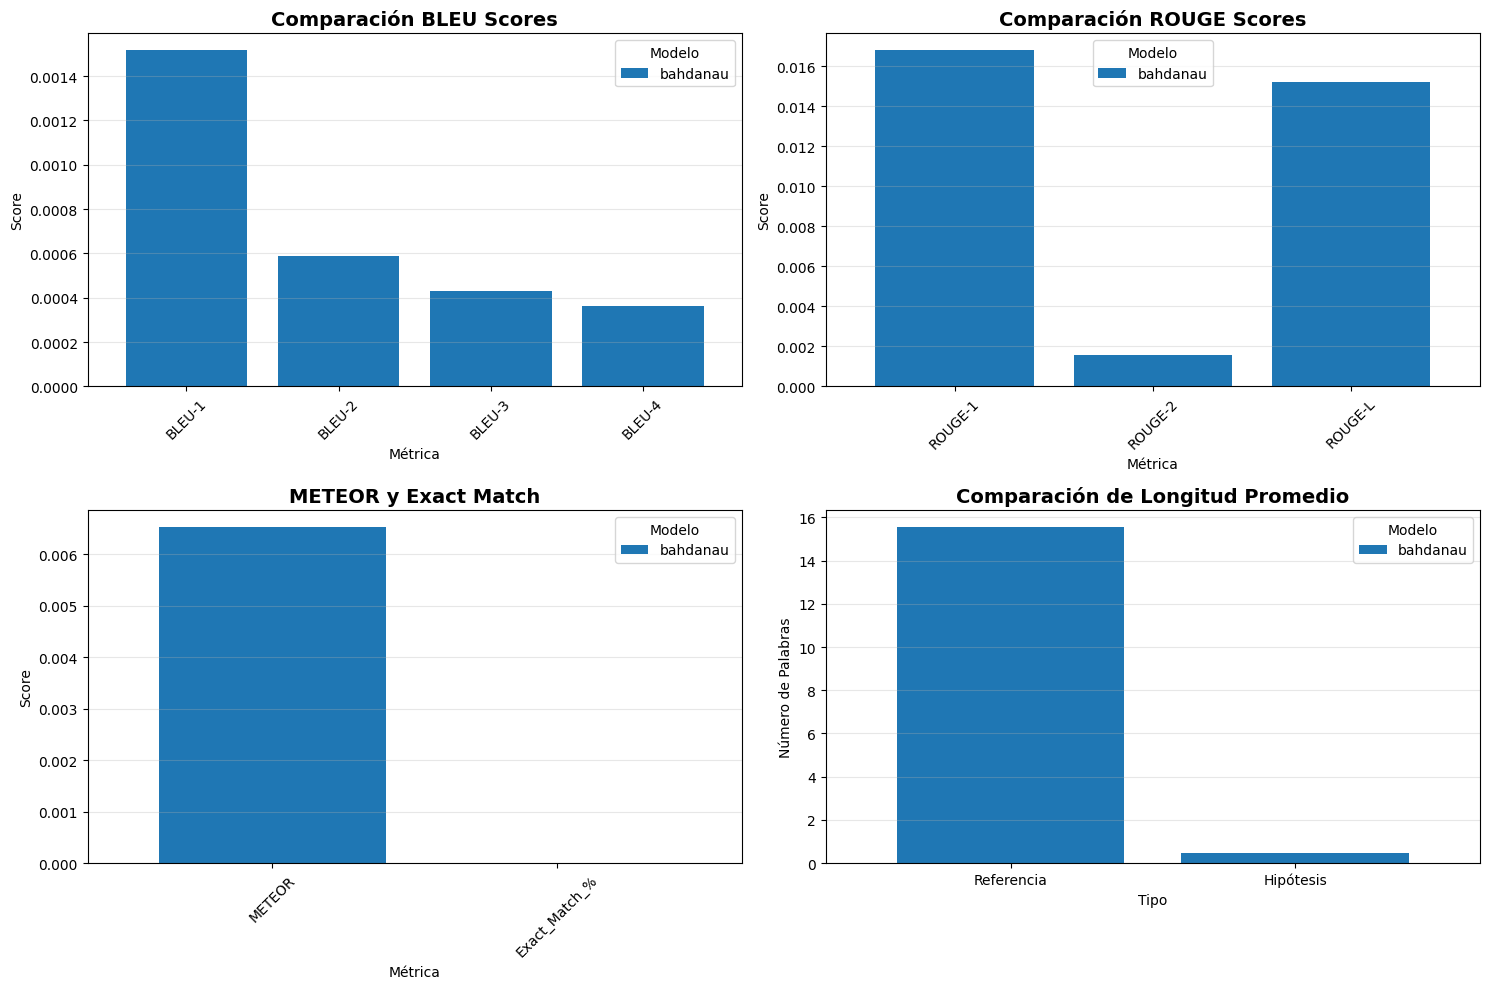

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# BLEU scores
bleu_metrics = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
bleu_data = results_df[bleu_metrics].T

ax = axes[0, 0]
bleu_data.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Comparación BLEU Scores', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Métrica')
ax.legend(title='Modelo')
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticklabels(bleu_metrics, rotation=45)

# ROUGE scores
rouge_metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
rouge_data = results_df[rouge_metrics].T

ax = axes[0, 1]
rouge_data.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Comparación ROUGE Scores', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Métrica')
ax.legend(title='Modelo')
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticklabels(rouge_metrics, rotation=45)

# METEOR y Exact Match
other_metrics = ['METEOR', 'Exact_Match_%']
other_data = results_df[other_metrics].T

ax = axes[1, 0]
other_data.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('METEOR y Exact Match', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Métrica')
ax.legend(title='Modelo')
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticklabels(other_metrics, rotation=45)

# Length comparison
length_metrics = ['Ref_Avg_Length', 'Hyp_Avg_Length']
length_data = results_df[length_metrics].T

ax = axes[1, 1]
length_data.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Comparación de Longitud Promedio', fontsize=14, fontweight='bold')
ax.set_ylabel('Número de Palabras')
ax.set_xlabel('Tipo')
ax.legend(title='Modelo')
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticklabels(['Referencia', 'Hipótesis'], rotation=0)

plt.tight_layout()
plt.savefig('comparacion_metricas_general.png', dpi=300, bbox_inches='tight')
plt.show()